<a href="https://colab.research.google.com/github/Plumz17/PP_Assignment02/blob/main/PP_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Second Pattern Recognition Assignment - Analysis of Audio Feature Representation - Anders Emmanuel Tan (24/541351/PA/22964)

Description: In this Assignment, I will be implementing three methods of extracting time domain features from audio files. These three features are:
1.   Histogram of Energy
2.   Histogram of Zero Crossing Rate
3.   Histogram of Energy Entropy

To Achieve this, I won't be using any external libraries to extract these features automatically. However, I will use libraries to help import and modify the audio files.

## 0. Preparing the Audio Files

Since the uploaded files in Google Colab are only available in the runtime, I will be attaining the audio files by cloning them from the Github Submission link. The Following code will be used to obtain all of the audio data from my github repository and clone them into the "PP_Assignment02" folder in google colab.

In [130]:
# Cloning Github Repository to get the Audio files
!rm -rf PP_Assignment02
!git clone https://github.com/Plumz17/PP_Assignment02

Cloning into 'PP_Assignment02'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 21 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 15.34 MiB | 15.09 MiB/s, done.
Resolving deltas: 100% (5/5), done.


## 1. Loading the Audio Files
In this section, we will import the necessary libraries which are numpy, matplotlib, and wave (to manipulate, visualize, and import the audio files). Afterwards, we will load the audio from our cloned repository, the function below will return the numeric representation of the audio as well as the audio's sample rate. Since we're gonna test the feature extraction methods to multiple audio files, we can store the values in an audios and sample rates array respectively. Lastly, we're also gonna create a helper function to help visualize the audio's waveform and to visualize the resulting histogram of the later sections.

In [131]:
#Import important libraries
import wave
import numpy as np
import matplotlib.pyplot as plt

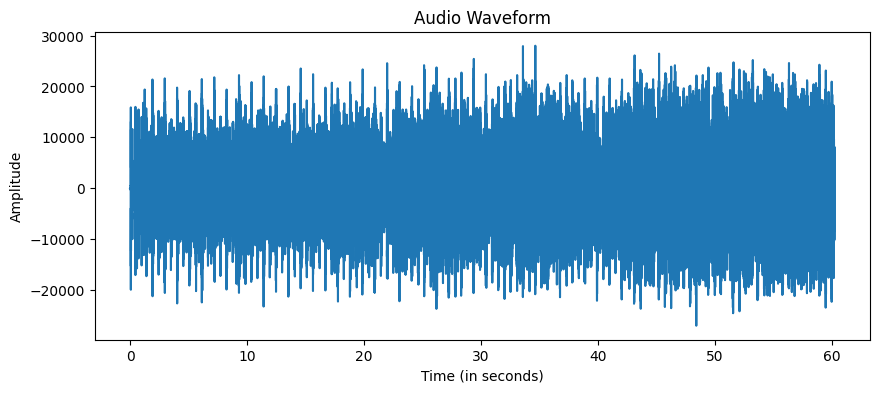

Sample Rate of music1.wav: 44100


In [132]:
def load_audio(filepath):
  #Opens files
  wf = wave.open(filepath, 'rb')
  #Reads metadata to get total number of audio samples and sample rate
  n_frames = wf.getnframes()
  sample_rate = wf.getframerate()
  #Reads all frames from the file
  audio = wf.readframes(n_frames)
  #Converts the raw data to integers then floats
  audio = np.frombuffer(audio, dtype=np.int16)
  audio = audio.astype(np.float32)
  wf.close()
  return audio, sample_rate

def plot_waveform(audio, sample_rate):
  time_axis = [i / sample_rate for i in range(len(audio))]
  plt.figure(figsize=(10,4))
  plt.plot(time_axis, audio)

  plt.title("Audio Waveform")
  plt.xlabel("Time (in seconds)")
  plt.ylabel("Amplitude")

  plt.show()

def plot_histogram(hist, bin_edges, method):
  plt.figure(figsize=(6,4))
  plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges))
  plt.title(f"Histogram of {method}")
  plt.xlabel(method)
  plt.ylabel("Frequency")
  plt.show()

# You can insert your own audio file in the /content/PP_Assignment02 if you wanna try additional files (and dont forget to at the file path to the array)
audio_files = [
  "/content/PP_Assignment02/music1.wav",
  "/content/PP_Assignment02/speech1.wav"
]

audios = []
sample_rates = []

for file in audio_files:
  audio, sr = load_audio(file)
  audios.append(audio)
  sample_rates.append(sr)

plot_waveform(audios[0], sample_rates[0])
print(f"Sample Rate of music1.wav: {sample_rates[0]}")

## 2. Audio Windowing
Before we can implement the Feature Extraction methods, we have to do something called Windowing.Since signals/audios is continuous, we want to extract information from a small enough region so that the resulting spectral information could be useful. To achieve this, we can divide the signal into several "frames" or windows with a certain overlap between windows (usually 50% of the window size). For this implementation, i will use rectangular window for the sake of simplicity with a default window size of 1024 and an overlap of 512.

In [133]:
def audio_windowing(audio, window_size=1024, overlap=512):
  windows = []
  for i in range(0, len(audio) - window_size, overlap):
    window = audio[i:i+window_size]
    windows.append(window)
  return windows

music1_windows = audio_windowing(audios[0])
speech1_windows = audio_windowing(audios[1])
print(f"Number of extracted audio of music1.wav: {len(music1_windows)}")
print(f"first 5 windows of music1.wav: {music1_windows[0:4]}")

Number of extracted audio of music1.wav: 5188
first 5 windows of music1.wav: [array([ 0.,  0.,  0., ...,  0., -1.,  1.], dtype=float32), array([ 0.,  2., -3., ...,  1.,  0.,  0.], dtype=float32), array([  0.,  -1.,   1., ..., -38., -25.,  -8.], dtype=float32), array([ -1.,   2.,  -3., ..., -78., -85., -96.], dtype=float32)]


## 3. Audio Energy and Histogram of Energy
Histogram of Energy is the first feature extraction method we will implement to represent each window in a numeric form. In part 3A, I will implement a function to compute the energy of a specific frame, this can be done by finding the sum of the square of the amplitudes in the aforementioned window. Afterwards in part 3B, we will be storing each of the window's energy in a histogram and we will also normilize this histogram. Finally, in 3C, we're gonna compare and analyze the Histogram of music1.wav and speech1.wav

### 3A. Audio Energy

In [134]:
def compute_energy(window):
  energy = 0
  for sample in window:
      energy += sample * sample
  return energy
print(f"First Window's Energy: {compute_energy(windows[0])}")

First Window's Energy: 4391.0


### 3B. Histogram of Energy

In [135]:
def histogram_of_energy(windows, bins=256):
  energies = []
  for window in windows:
    e = compute_energy(window)
    energies.append(e)
  hist, bin_edges = np.histogram(energies, bins=bins)
  hist = hist / np.sum(hist)
  return hist, bin_edges

music1_histogram_energy, music1_bin_edges = histogram_of_energy(music1_windows)
speech1_histogram_energy, speech1_bin_edges = histogram_of_energy(speech1_windows)
print(f"First 5 values of the Histograms: {music1_histogram_energy[0:4]}")

First 5 values of the Histograms: [0.00212028 0.00077101 0.00154202 0.00231303]


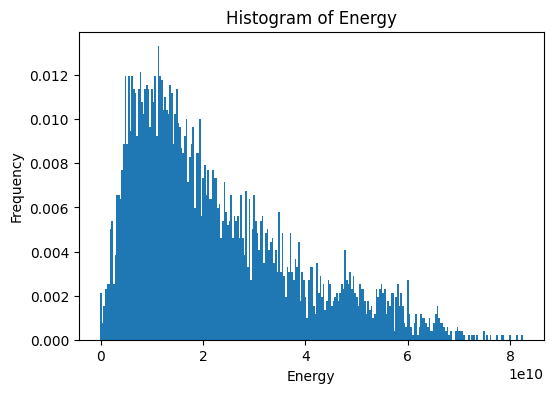

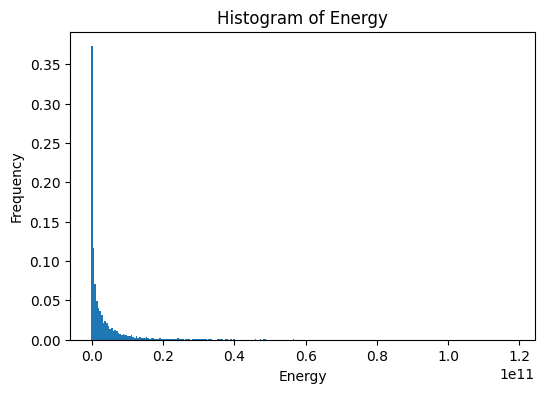

In [136]:
plot_histogram(music1_histogram_energy, music1_bin_edges, "Energy")
plot_histogram(speech1_histogram_energy, speech1_bin_edges, "Energy")

### 3C. Analysis
From the Histogram of Energy for both normal human speech and music. We can observe that in the speech audio, the resulting histogram is skewed left since there are lots of low energy windows from pauses, breathing, and consonants with a long tail of occasional high energy bursts (mostly vowels). On the other hand, music's histogram is more spread out with fewer silent windows and more middling to high energy. As you can see, the difference between music and speech histogram of energy is night and day, we can use this insight to create a speech vs music detection algorithm in the future.

## 4. Zero Crossing Rate and Histogram of ZCR
The next feature extraction method we will be implementing is Zero Crossing Rate (ZCR). This method captures the frequency in which a signal changes signs (from positive to negative, vice versa, hence the name). Similar to the previous section, I will be implementing a function to calculate the ZCR of a specific window in part 4A, and then turning that into a histogram of ZCR in part 4B, as well as comparing music vs speech in part 4C.

### 4A. Zero Crossing Rate

In [137]:
def compute_zcr(window):
  count = 0
  for i in range(1, len(window)):
    if window[i-1] * window[i] < 0:
      count += 1
  #Normalize
  return count / len(window)
print(f"First Window's ZCR of music1.wav: {compute_zcr(music1_windows[0])}")

First Window's ZCR of music1.wav: 0.68359375


### 4B. Histogram of Zero Crossing Rate

In [140]:
def histogram_of_zcr(windows, bins=256):
  zcrs = []
  for window in windows:
    e = compute_zcr(window)
    zcrs.append(e)
  hist, bin_edges = np.histogram(zcrs, bins=bins)
  hist = hist / np.sum(hist)
  return hist, bin_edges

music1_histogram_zcr, music1_bin_edges = histogram_of_zcr(music1_windows)
speech1_histogram_zcr, speech1_bin_edges = histogram_of_zcr(speech1_windows)
print(f"First 5 values of the Histograms: {music1_histogram_zcr[0:4]}")

First 5 values of the Histograms: [0.00154202 0.00250578 0.00269854 0.00173477]


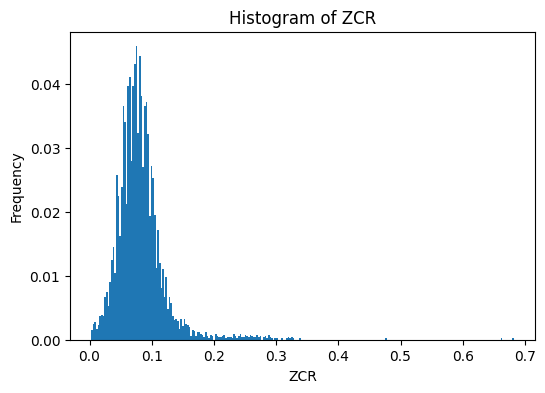

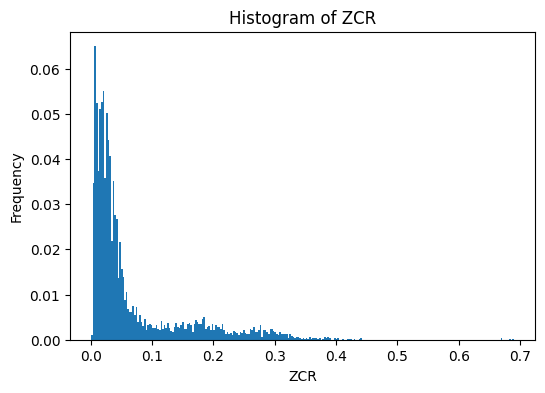

In [141]:
plot_histogram(music1_histogram_zcr, music1_bin_edges, "ZCR")
plot_histogram(speech1_histogram_zcr, speech1_bin_edges, "ZCR")

### 4C. Analysis
From the Histogram of ZCR for both normal human speech and music. We can observe that in the speech audio, the resulting histogram has a dominant spike in the left (very low ZCR values), this is probably because speech audios contain many sounds which are more periodic and change smoothly over time, resulting in fewer zero crossings. On contrast, music signals often contain a wider range of frequencies, instruments, percussion, and noisier components, which cause the waveform to cross the zero axis more frequently.

## 5. Energy Enthropy and Histogram of Energy Enthropy
The next feature extraction method we will be implementing is Histogram of Energy Enthropy.

## X. References (Source of the Audio)
1.   music1.wav - Never Gonna Give You Up by Rick Astley (https://www.youtube.com/watch?v=dQw4w9WgXcQ)
2.   speech1.wav - Believe in Yourself by Markiplier (https://www.youtube.com/watch?v=Nn7d6Bnbr28)

